In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

In [2]:
adata = sc.read_h5ad('../sim_data/adata/adata_100.h5ad')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [3]:
counts_mean = np.mean(adata.X, axis=0)
counts_sum = np.sum(adata.X, axis=0)
nnz = np.count_nonzero(adata.X, axis=0)
proportion = 1-np.count_nonzero(adata.X, axis=0)/adata.X.shape[0]

In [12]:
pro = proportion/(1-proportion)

In [13]:
K = pro * counts_sum/adata.X.shape[0]

In [10]:
x = np.arange(adata.X.shape[1])

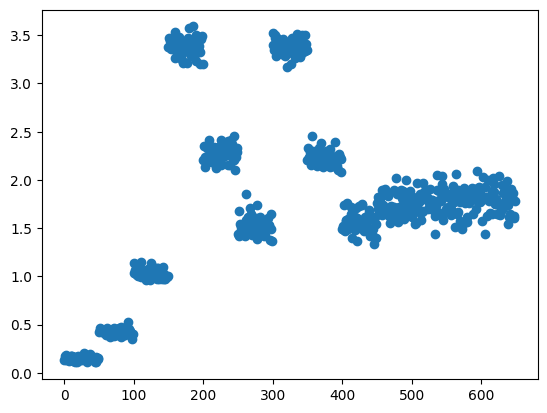

In [14]:
plt.scatter(x, K)

(array([ 92.,   8.,  50.,  38., 201.,  86.,  75.,   0.,   7.,  93.]),
 array([0.10661002, 0.45508693, 0.80356384, 1.15204075, 1.50051765,
        1.84899456, 2.19747147, 2.54594837, 2.89442528, 3.24290219,
        3.59137909]),
 <BarContainer object of 10 artists>)

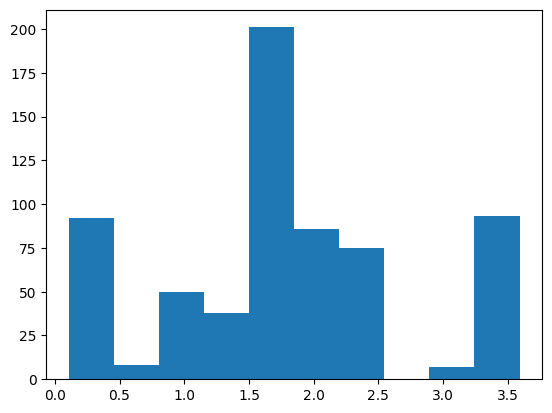

In [15]:
plt.hist(K)

In [ ]:
res = counts_sum/adata.X.shape[0] * np.log(counts_sum+1)/nnz

In [15]:
np.median(res)

np.float64(2.1558545369368334)

In [14]:
np.mean(res)

np.float64(2.8530029955329863)

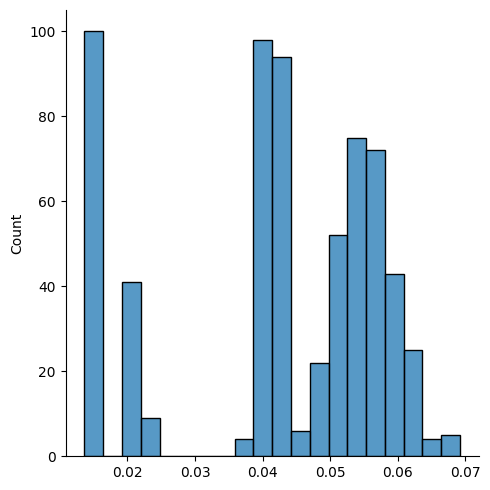

In [17]:
sns.displot(res, bins=20)

<Axes: ylabel='Density'>

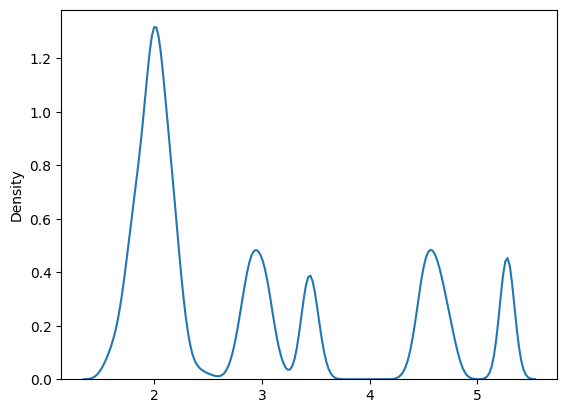

In [88]:
sns.kdeplot(res, bw_adjust=.2)

In [13]:
from sklearn.mixture import GaussianMixture

In [103]:
def drop_filter(X, bw_adjust):

    counts_sum = np.sum(X, axis=0)
    nnz = np.count_nonzero(X, axis=0)
    res = counts_sum/nnz

    kde = sns.kdeplot(res, bw_adjust=bw_adjust)
    x_data = kde.get_lines()[0].get_xdata()
    y_data = kde.get_lines()[0].get_ydata()

    plt.close()  

    peaks, _ = find_peaks(y_data, height=0)

    if len(peaks) >= 2:
        first_peak = peaks[0]
        second_peak = peaks[1]

        # detect valley
        valley_idx = np.argmin(y_data[first_peak:second_peak]) + first_peak
        valley_x = x_data[valley_idx]
        valley_y = y_data[valley_idx]

        plt.plot(x_data, y_data)
        plt.plot(x_data[peaks], y_data[peaks], "ro", label="Peaks")
        plt.plot(valley_x, valley_y, "go", label="Valley (between first 2 peaks)")
        plt.legend()
        plt.show()
        feature_indices = np.where(res>valley_x)[0]
        return feature_indices

    else:
        print("there are not 2 valleys")
        return np.arange(X.shape[1])

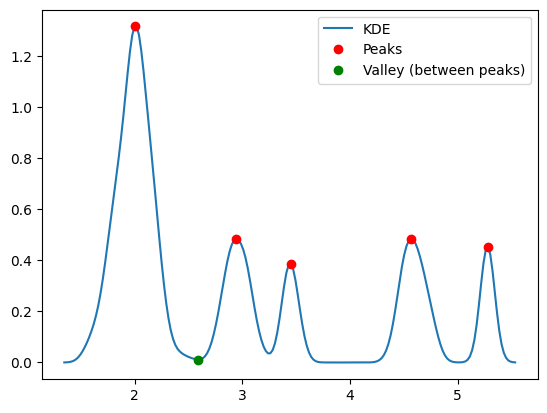

First Peak: x = 1.999
Second Peak: x = 2.946
Valley: x = 2.588


In [91]:
valley_x = drop_filter(res, .2)

In [99]:
feature_indices = np.where(res>valley_x)[0]

In [95]:
res[101]

np.float64(2.2098701089115464)

<Axes: >

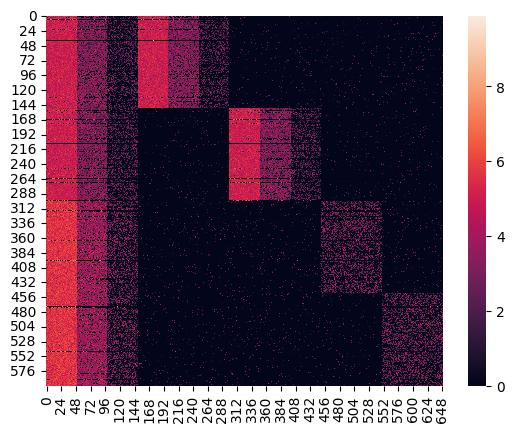

In [94]:
sns.heatmap(adata.X)

<Axes: >

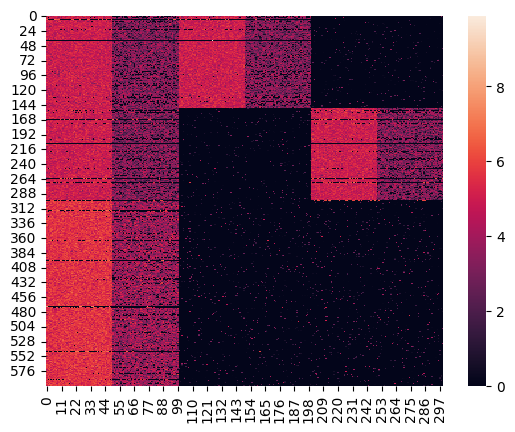

In [100]:
sns.heatmap(adata.X[:, feature_indices])